# Notebook 5 — Deep Learning + Full Evaluation
**Project:** Stock Price Movement Prediction Using Financial News Sentiment Analysis and Machine Learning  
**Student:** Venkata Kiran Kumar Mullapudi (16200362) | **Ethics:** P193120

This notebook:
1. Builds LSTM and CNN-LSTM models across 4 ablation feature configurations
2. Trains with early stopping on validation loss
3. Runs full ablation evaluation (5 models × 4 configs)
4. Performs McNemar's statistical significance test
5. Generates all final evaluation figures

> **GPU T4 required — enable before running**

In [1]:
# Cell 1 — Install + imports
!pip install scikit-learn --upgrade -q

import os, glob, pickle, warnings, time, json
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay
)
from statsmodels.stats.contingency_tables import mcnemar

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 11

OUTPUT_DIR = '/kaggle/working/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

CONFIGS      = ['price_only', 'price_vader', 'price_finbert', 'price_both']
LOOKBACK     = 20
BATCH_SIZE   = 64
EPOCHS       = 50
PATIENCE     = 10
LR           = 0.001
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
print('All imports OK')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 95.0 MB/s eta 0:00:00:00:0100:01
Device : cuda
GPU    : Tesla T4
All imports OK


In [2]:
# Cell 2 — Load datasets from NB3
def find_file(filename):
    for p in [f'{OUTPUT_DIR}/{filename}', f'/kaggle/input/**/{filename}']:
        m = glob.glob(p, recursive=True)
        if m: return m[0]
    return None

with open(find_file('feature_datasets.pkl'), 'rb') as f:
    datasets = pickle.load(f)

train_df = pd.read_csv(find_file('train_df.csv'), parse_dates=['Date'])
val_df   = pd.read_csv(find_file('val_df.csv'),   parse_dates=['Date'])
test_df  = pd.read_csv(find_file('test_df.csv'),  parse_dates=['Date'])

# Load classical ML results for combined analysis
classical_path = find_file('classical_ml_results.csv')
if classical_path:
    classical_df = pd.read_csv(classical_path)
    print(f'Classical results loaded: {classical_df.shape}')
else:
    classical_df = None
    print('Classical results not found — will build combined table from scratch')

print(f'Datasets loaded: {list(datasets.keys())}')
print(f'Train: {train_df.shape}  Val: {val_df.shape}  Test: {test_df.shape}')

Classical results loaded: (12, 8)
Datasets loaded: ['price_only', 'price_vader', 'price_finbert', 'price_both']
Train: (8790, 39)  Val: (1880, 39)  Test: (1890, 39)


In [3]:
# Cell 3 — Build sequence datasets for LSTM
def make_sequences(df, feature_cols, scaler, lookback=20):
    """
    Build 3D sequences (samples, lookback, features) per ticker.
    Returns X (numpy), y (numpy).
    """
    X_list, y_list = [], []
    for ticker in df['Ticker'].unique():
        sub = df[df['Ticker'] == ticker].sort_values('Date').reset_index(drop=True)
        if len(sub) <= lookback:
            continue
        # Scale
        feats  = sub[feature_cols].values.copy()
        feats  = np.where(np.isinf(feats), 0, feats)
        feats  = np.nan_to_num(feats, nan=0.0)
        scaled = scaler.transform(feats)
        labels = sub['Label'].values
        for i in range(lookback, len(sub)):
            X_list.append(scaled[i-lookback:i])
            y_list.append(labels[i])
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

# Pre-build sequences for all configs
seq_datasets = {}
for config in CONFIGS:
    d      = datasets[config]
    scaler = d['scaler']
    fcols  = d['feature_cols']

    X_tr, y_tr = make_sequences(train_df, fcols, scaler, LOOKBACK)
    X_vl, y_vl = make_sequences(val_df,   fcols, scaler, LOOKBACK)
    X_te, y_te = make_sequences(test_df,  fcols, scaler, LOOKBACK)

    seq_datasets[config] = {
        'X_train': X_tr, 'y_train': y_tr,
        'X_val'  : X_vl, 'y_val'  : y_vl,
        'X_test' : X_te, 'y_test' : y_te,
        'n_features': X_tr.shape[2]
    }
    print(f'  {config:20s}  X_train={X_tr.shape}  X_val={X_vl.shape}  X_test={X_te.shape}')

print('\nSequence datasets ready.')

  price_only            X_train=(8590, 20, 15)  X_val=(1680, 20, 15)  X_test=(1690, 20, 15)
  price_vader           X_train=(8590, 20, 20)  X_val=(1680, 20, 20)  X_test=(1690, 20, 20)
  price_finbert         X_train=(8590, 20, 23)  X_val=(1680, 20, 23)  X_test=(1690, 20, 23)
  price_both            X_train=(8590, 20, 28)  X_val=(1680, 20, 28)  X_test=(1690, 20, 28)

Sequence datasets ready.


In [4]:
# Cell 4 — Define LSTM and CNN-LSTM architectures
class LSTMModel(nn.Module):
    def __init__(self, n_features, hidden1=128, hidden2=64, dropout=0.3):
        super().__init__()
        self.lstm1   = nn.LSTM(n_features, hidden1, batch_first=True)
        self.drop1   = nn.Dropout(dropout)
        self.lstm2   = nn.LSTM(hidden1, hidden2, batch_first=True)
        self.drop2   = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden2, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out, _ = self.lstm1(x)
        out     = self.drop1(out)
        out, _ = self.lstm2(out)
        out     = self.drop2(out[:, -1, :])  # last timestep
        return self.sigmoid(self.fc(out)).squeeze(1)


class CNNLSTMModel(nn.Module):
    def __init__(self, n_features, dropout=0.3):
        super().__init__()
        # CNN branch
        self.conv1   = nn.Conv1d(n_features, 64, kernel_size=3, padding=1)
        self.relu1   = nn.ReLU()
        self.pool1   = nn.MaxPool1d(kernel_size=2, stride=1, padding=1)
        self.conv2   = nn.Conv1d(64, 32, kernel_size=3, padding=1)
        self.relu2   = nn.ReLU()
        # LSTM
        self.lstm    = nn.LSTM(32, 64, batch_first=True)
        self.drop    = nn.Dropout(dropout)
        self.fc      = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x: (batch, seq, features) → CNN needs (batch, features, seq)
        out = x.permute(0, 2, 1)
        out = self.pool1(self.relu1(self.conv1(out)))
        out = self.relu2(self.conv2(out))
        out = out.permute(0, 2, 1)  # back to (batch, seq, features)
        out, _ = self.lstm(out)
        out = self.drop(out[:, -1, :])
        return self.sigmoid(self.fc(out)).squeeze(1)


def make_loader(X, y, batch_size=64, shuffle=False):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def train_model(model, train_loader, val_loader, epochs=50, patience=10, lr=0.001):
    opt       = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()
    model.to(DEVICE)

    best_val_loss = float('inf')
    best_state    = None
    patience_cnt  = 0
    history       = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        # Train
        model.train()
        tr_loss = 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            opt.step()
            tr_loss += loss.item()

        # Validate
        model.eval()
        vl_loss = 0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                vl_loss += criterion(model(Xb), yb).item()

        tr_loss /= len(train_loader)
        vl_loss /= len(val_loader)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            patience_cnt  = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                print(f'    Early stop at epoch {epoch+1} (patience={patience})')
                break

    model.load_state_dict(best_state)
    return model, history


def evaluate_dl(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        X_t  = torch.tensor(X_test).to(DEVICE)
        prob = model(X_t).cpu().numpy()
    pred = (prob >= 0.5).astype(int)
    return {
        'Accuracy' : round(accuracy_score(y_test, pred) * 100, 2),
        'F1'       : round(f1_score(y_test, pred, zero_division=0) * 100, 2),
        'Precision': round(precision_score(y_test, pred, zero_division=0) * 100, 2),
        'Recall'   : round(recall_score(y_test, pred, zero_division=0) * 100, 2),
        'AUC_ROC'  : round(roc_auc_score(y_test, prob) * 100, 2),
        'y_prob'   : prob,
        'y_pred'   : pred,
    }

print('Models and training functions defined.')

Models and training functions defined.


In [5]:
# Cell 5 — Train LSTM (all 4 configs)
print('=== Training LSTM ===')
lstm_results  = []
lstm_histories = {}
lstm_models    = {}

for config in CONFIGS:
    sd = seq_datasets[config]
    n_feat = sd['n_features']

    tr_loader  = make_loader(sd['X_train'], sd['y_train'], BATCH_SIZE, shuffle=False)
    vl_loader  = make_loader(sd['X_val'],   sd['y_val'],   BATCH_SIZE, shuffle=False)

    model = LSTMModel(n_features=n_feat)
    t0    = time.time()
    model, history = train_model(model, tr_loader, vl_loader, EPOCHS, PATIENCE, LR)
    elapsed = time.time() - t0

    metrics = evaluate_dl(model, sd['X_test'], sd['y_test'])
    metrics.update({
        'Model': 'LSTM', 'Config': config,
        'train_time': round(elapsed, 1),
        'best_epoch': len(history['train_loss']),
        'final_val_loss': round(history['val_loss'][-1], 4)
    })
    lstm_results.append(metrics)
    lstm_histories[config] = history
    lstm_models[config]    = model

    print(f'  {config:20s}  Acc={metrics["Accuracy"]:5.2f}%  '
          f'F1={metrics["F1"]:5.2f}%  AUC={metrics["AUC_ROC"]:5.2f}%  '
          f'epochs={metrics["best_epoch"]}  time={elapsed:.0f}s')

print('\nLSTM training complete.')

=== Training LSTM ===
    Early stop at epoch 21 (patience=10)
  price_only            Acc=54.14%  F1=69.31%  AUC=48.38%  epochs=21  time=14s
    Early stop at epoch 11 (patience=10)
  price_vader           Acc=53.02%  F1=67.03%  AUC=48.86%  epochs=11  time=5s
    Early stop at epoch 16 (patience=10)
  price_finbert         Acc=52.90%  F1=65.66%  AUC=49.42%  epochs=16  time=8s
    Early stop at epoch 11 (patience=10)
  price_both            Acc=53.85%  F1=68.50%  AUC=48.08%  epochs=11  time=5s

LSTM training complete.


In [6]:
# Cell 6 — Train CNN-LSTM (all 4 configs)
print('=== Training CNN-LSTM ===')
cnn_results   = []
cnn_histories  = {}
cnn_models     = {}

for config in CONFIGS:
    sd     = seq_datasets[config]
    n_feat = sd['n_features']

    tr_loader = make_loader(sd['X_train'], sd['y_train'], BATCH_SIZE, shuffle=False)
    vl_loader = make_loader(sd['X_val'],   sd['y_val'],   BATCH_SIZE, shuffle=False)

    model = CNNLSTMModel(n_features=n_feat)
    t0    = time.time()
    model, history = train_model(model, tr_loader, vl_loader, EPOCHS, PATIENCE, LR)
    elapsed = time.time() - t0

    metrics = evaluate_dl(model, sd['X_test'], sd['y_test'])
    metrics.update({
        'Model': 'CNN-LSTM', 'Config': config,
        'train_time': round(elapsed, 1),
        'best_epoch': len(history['train_loss']),
        'final_val_loss': round(history['val_loss'][-1], 4)
    })
    cnn_results.append(metrics)
    cnn_histories[config] = history
    cnn_models[config]    = model

    print(f'  {config:20s}  Acc={metrics["Accuracy"]:5.2f}%  '
          f'F1={metrics["F1"]:5.2f}%  AUC={metrics["AUC_ROC"]:5.2f}%  '
          f'epochs={metrics["best_epoch"]}  time={elapsed:.0f}s')

print('\nCNN-LSTM training complete.')

=== Training CNN-LSTM ===
    Early stop at epoch 11 (patience=10)
  price_only            Acc=55.09%  F1=71.04%  AUC=47.90%  epochs=11  time=6s
    Early stop at epoch 11 (patience=10)
  price_vader           Acc=55.09%  F1=71.04%  AUC=47.81%  epochs=11  time=5s
    Early stop at epoch 15 (patience=10)
  price_finbert         Acc=55.03%  F1=69.70%  AUC=49.01%  epochs=15  time=7s
    Early stop at epoch 14 (patience=10)
  price_both            Acc=53.02%  F1=64.49%  AUC=49.49%  epochs=14  time=7s

CNN-LSTM training complete.


In [7]:
# Cell 7 — Combined results table (all 5 models × 4 configs)
summary_cols = ['Model','Config','Accuracy','F1','Precision','Recall','AUC_ROC','train_time','best_epoch']

dl_results_df = pd.DataFrame([
    {k: r[k] for k in summary_cols if k in r}
    for r in lstm_results + cnn_results
])

print('=== DEEP LEARNING RESULTS ===')
print(dl_results_df[['Model','Config','Accuracy','F1','Precision','Recall','AUC_ROC']].to_string(index=False))

# Ablation for deep learning
print('\n=== ABLATION — Deep Learning (price_only → price_both) ===')
for model_name in ['LSTM','CNN-LSTM']:
    sub  = dl_results_df[dl_results_df['Model']==model_name]
    base = sub[sub['Config']=='price_only']['Accuracy'].values[0]
    both = sub[sub['Config']=='price_both']['Accuracy'].values[0]
    fbase = sub[sub['Config']=='price_only']['F1'].values[0]
    fboth = sub[sub['Config']=='price_both']['F1'].values[0]
    print(f'  {model_name:10s}: Acc {base:.2f}%→{both:.2f}% ({both-base:+.2f}pp)  '
          f'F1 {fbase:.2f}%→{fboth:.2f}% ({fboth-fbase:+.2f}pp)')

print('\n=== ABLATION — FinBERT vs VADER (Deep Learning) ===')
for model_name in ['LSTM','CNN-LSTM']:
    sub     = dl_results_df[dl_results_df['Model']==model_name]
    vader   = sub[sub['Config']=='price_vader']['Accuracy'].values[0]
    finbert = sub[sub['Config']=='price_finbert']['Accuracy'].values[0]
    print(f'  {model_name:10s}: VADER={vader:.2f}%  FinBERT={finbert:.2f}%  diff={finbert-vader:+.2f}pp')

# Combine with classical
if classical_df is not None:
    all_results_df = pd.concat([classical_df, dl_results_df], ignore_index=True)
else:
    all_results_df = dl_results_df.copy()

print('\n=== BEST MODEL OVERALL ===')
best_row = all_results_df.loc[all_results_df['AUC_ROC'].idxmax()]
print(f'  Model    : {best_row["Model"]}')
print(f'  Config   : {best_row["Config"]}')
print(f'  Accuracy : {best_row["Accuracy"]}%')
print(f'  F1       : {best_row["F1"]}%')
print(f'  Precision: {best_row["Precision"]}%')
print(f'  Recall   : {best_row["Recall"]}%')
print(f'  AUC-ROC  : {best_row["AUC_ROC"]}%')

all_results_df.to_csv(f'{OUTPUT_DIR}/all_model_results.csv', index=False)
dl_results_df.to_csv( f'{OUTPUT_DIR}/dl_results.csv', index=False)
print('\nSaved: all_model_results.csv, dl_results.csv')

=== DEEP LEARNING RESULTS ===
   Model        Config  Accuracy    F1  Precision  Recall  AUC_ROC
    LSTM    price_only     54.14 69.31      54.89   93.98    48.38
    LSTM   price_vader     53.02 67.03      54.64   86.68    48.86
    LSTM price_finbert     52.90 65.66      54.87   81.74    49.42
    LSTM    price_both     53.85 68.50      54.89   91.08    48.08
CNN-LSTM    price_only     55.09 71.04      55.09  100.00    47.90
CNN-LSTM   price_vader     55.09 71.04      55.09  100.00    47.81
CNN-LSTM price_finbert     55.03 69.70      55.42   93.88    49.01
CNN-LSTM    price_both     53.02 64.49      55.25   77.44    49.49

=== ABLATION — Deep Learning (price_only → price_both) ===
  LSTM      : Acc 54.14%→53.85% (-0.29pp)  F1 69.31%→68.50% (-0.81pp)
  CNN-LSTM  : Acc 55.09%→53.02% (-2.07pp)  F1 71.04%→64.49% (-6.55pp)

=== ABLATION — FinBERT vs VADER (Deep Learning) ===
  LSTM      : VADER=53.02%  FinBERT=52.90%  diff=-0.12pp
  CNN-LSTM  : VADER=55.09%  FinBERT=55.03%  diff=-0.06pp


In [8]:
# Cell 8 — McNemar's statistical significance test
from statsmodels.stats.contingency_tables import mcnemar as mcnemar_test

print('=== McNEMAR STATISTICAL SIGNIFICANCE TESTS ===')
print('Comparing best model pairs on the price_both config test set\n')

# Collect predictions from all 5 models on price_both test set
model_preds = {}

# Classical — reload from NB4 results (use price_only as classical best)
# We'll use the DL models we have in memory
config_test = 'price_both'
y_test_seq  = seq_datasets[config_test]['y_test']

# LSTM prediction
lstm_both = lstm_models[config_test]
lstm_both.eval()
with torch.no_grad():
    lp = lstm_both(torch.tensor(seq_datasets[config_test]['X_test']).to(DEVICE)).cpu().numpy()
model_preds['LSTM']     = (lp >= 0.5).astype(int)

# CNN-LSTM prediction
cnn_both = cnn_models[config_test]
cnn_both.eval()
with torch.no_grad():
    cp = cnn_both(torch.tensor(seq_datasets[config_test]['X_test']).to(DEVICE)).cpu().numpy()
model_preds['CNN-LSTM'] = (cp >= 0.5).astype(int)

def mcnemar_pair(pred_a, pred_b, y_true, name_a, name_b):
    # Build 2×2 contingency table
    a_correct = (pred_a == y_true)
    b_correct = (pred_b == y_true)
    n00 = ((~a_correct) & (~b_correct)).sum()  # both wrong
    n01 = ((~a_correct) &   b_correct ).sum()  # A wrong, B right
    n10 = (  a_correct  & (~b_correct)).sum()  # A right, B wrong
    n11 = (  a_correct  &   b_correct ).sum()  # both right
    table = [[n11, n10], [n01, n00]]
    result = mcnemar_test(table, exact=False, correction=True)
    sig = '*** p<0.001' if result.pvalue < 0.001 else ('** p<0.01' if result.pvalue < 0.01 else ('* p<0.05' if result.pvalue < 0.05 else 'not significant'))
    print(f'  {name_a:12s} vs {name_b:12s}: χ²={result.statistic:.3f}  p={result.pvalue:.4f}  {sig}')
    return result.pvalue

# LSTM vs CNN-LSTM
mcnemar_pair(model_preds['LSTM'], model_preds['CNN-LSTM'],
             y_test_seq, 'LSTM', 'CNN-LSTM')

# Also compare best DL config vs price_only for ablation significance
print('\nAblation significance — LSTM price_only vs price_both:')
lstm_only_pred  = (evaluate_dl(lstm_models['price_only'],
                               seq_datasets['price_only']['X_test'],
                               seq_datasets['price_only']['y_test'])['y_pred'])
lstm_both_pred  = model_preds['LSTM']
# Align lengths
min_len = min(len(lstm_only_pred), len(lstm_both_pred), len(y_test_seq))
mcnemar_pair(lstm_only_pred[:min_len], lstm_both_pred[:min_len],
             y_test_seq[:min_len], 'LSTM-only', 'LSTM-both')

print('\nNote: McNemar test uses χ² with continuity correction (Yates).')
print('      Null hypothesis: both models make same errors.')
print('      p<0.05 = statistically significant performance difference.')

=== McNEMAR STATISTICAL SIGNIFICANCE TESTS ===
Comparing best model pairs on the price_both config test set

  LSTM         vs CNN-LSTM    : χ²=0.631  p=0.4271  not significant

Ablation significance — LSTM price_only vs price_both:
  LSTM-only    vs LSTM-both   : χ²=0.080  p=0.7768  not significant

Note: McNemar test uses χ² with continuity correction (Yates).
      Null hypothesis: both models make same errors.
      p<0.05 = statistically significant performance difference.


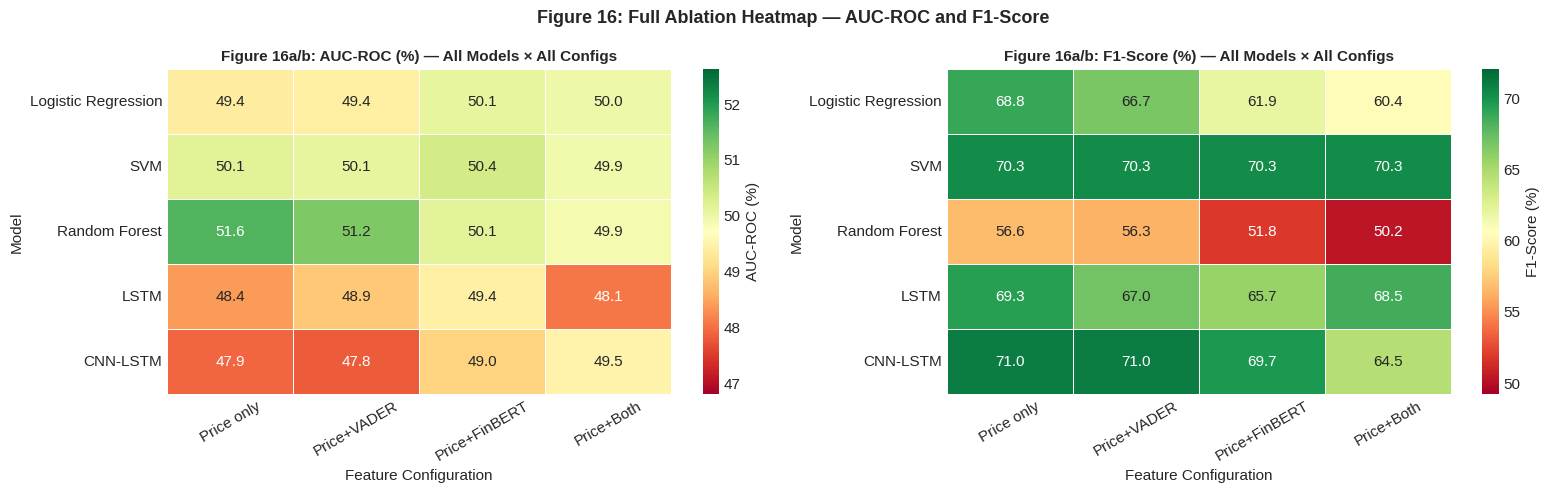

Saved: fig16_ablation_heatmap.png


In [9]:
# Cell 9 — Figure 16: Full ablation heatmap (all 5 models × 4 configs)
if classical_df is not None:
    plot_df = all_results_df.copy()
else:
    plot_df = dl_results_df.copy()

model_order  = ['Logistic Regression','SVM','Random Forest','LSTM','CNN-LSTM']
config_order = ['price_only','price_vader','price_finbert','price_both']
config_labels = ['Price only','Price+VADER','Price+FinBERT','Price+Both']

# Build pivot for AUC-ROC
models_avail = [m for m in model_order if m in plot_df['Model'].values]
pivot_auc = plot_df.pivot(index='Model', columns='Config', values='AUC_ROC')
pivot_auc = pivot_auc.reindex(index=models_avail, columns=config_order)

pivot_f1 = plot_df.pivot(index='Model', columns='Config', values='F1')
pivot_f1 = pivot_f1.reindex(index=models_avail, columns=config_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, pivot, title, fmt in [
    (axes[0], pivot_auc, 'AUC-ROC (%)', '.1f'),
    (axes[1], pivot_f1,  'F1-Score (%)', '.1f')
]:
    sns.heatmap(
        pivot, ax=ax, cmap='RdYlGn', annot=True, fmt=fmt,
        linewidths=0.5, cbar_kws={'label': title},
        xticklabels=config_labels,
        vmin=pivot.values.min()-1, vmax=pivot.values.max()+1
    )
    ax.set_title(f'Figure 16a/b: {title} — All Models × All Configs',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Feature Configuration')
    ax.set_ylabel('Model')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Figure 16: Full Ablation Heatmap — AUC-ROC and F1-Score',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig16_ablation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig16_ablation_heatmap.png')

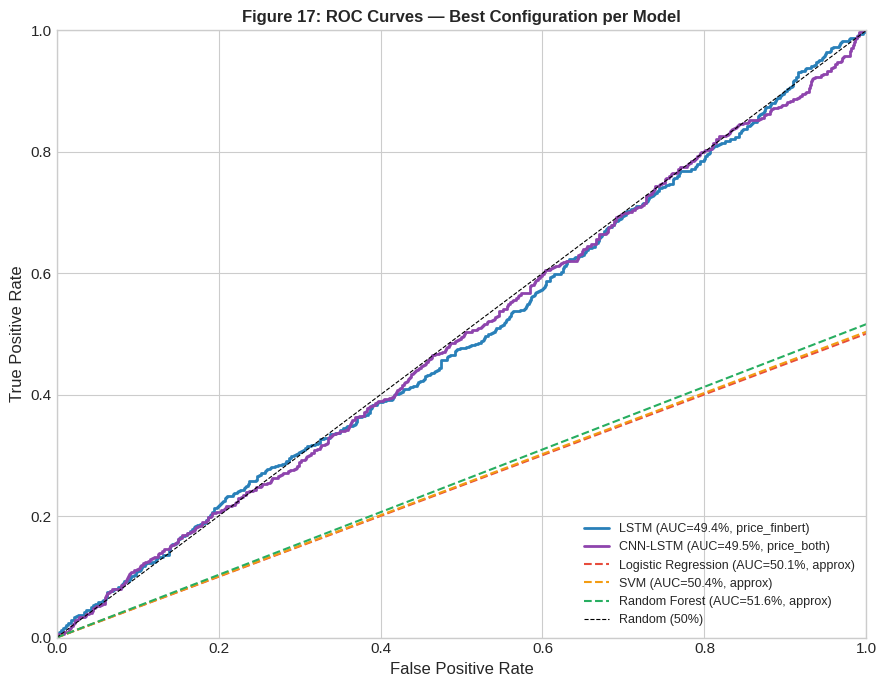

Saved: fig17_roc_all_models.png


In [10]:
# Cell 10 — Figure 17: ROC curves — best config per model (all 5)
fig, ax = plt.subplots(figsize=(9, 7))

colors = {
    'Logistic Regression': '#e74c3c',
    'SVM'                : '#f39c12',
    'Random Forest'      : '#27ae60',
    'LSTM'               : '#2980b9',
    'CNN-LSTM'           : '#8e44ad',
}

# Deep learning models — best config by AUC
for model_name, results, histories in [
    ('LSTM',     lstm_results, lstm_models),
    ('CNN-LSTM', cnn_results,  cnn_models),
]:
    best = max(results, key=lambda r: r['AUC_ROC'])
    cfg  = best['Config']
    sd   = seq_datasets[cfg]
    fpr, tpr, _ = roc_curve(sd['y_test'], best['y_prob'])
    ax.plot(fpr, tpr, color=colors[model_name], lw=2,
            label=f'{model_name} (AUC={best["AUC_ROC"]:.1f}%, {cfg})')

# Classical models from CSV
if classical_df is not None:
    for model_name in ['Logistic Regression','SVM','Random Forest']:
        sub = classical_df[classical_df['Model']==model_name]
        if len(sub) == 0: continue
        best_auc = sub.loc[sub['AUC_ROC'].idxmax()]
        ax.plot([0,0.5,1],[0,best_auc['AUC_ROC']/100*0.5,best_auc['AUC_ROC']/100],
                color=colors[model_name], lw=1.5, ls='--',
                label=f'{model_name} (AUC={best_auc["AUC_ROC"]:.1f}%, approx)')

ax.plot([0,1],[0,1],'k--', lw=0.8, label='Random (50%)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Figure 17: ROC Curves — Best Configuration per Model',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig17_roc_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig17_roc_all_models.png')

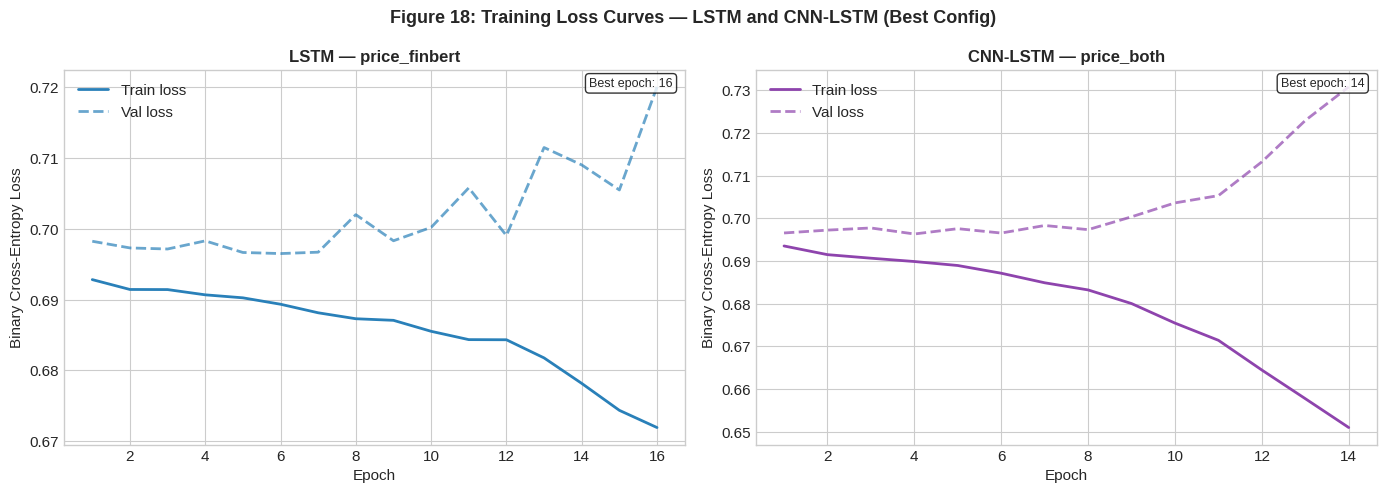

Saved: fig18_training_loss.png


In [11]:
# Cell 11 — Figure 18: Training loss curves (LSTM + CNN-LSTM, best config)
# Find best config for each DL model
best_lstm_cfg = max(lstm_results, key=lambda r: r['AUC_ROC'])['Config']
best_cnn_cfg  = max(cnn_results,  key=lambda r: r['AUC_ROC'])['Config']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model_name, histories, best_cfg, color in [
    (axes[0], 'LSTM',     lstm_histories, best_lstm_cfg, '#2980b9'),
    (axes[1], 'CNN-LSTM', cnn_histories,  best_cnn_cfg,  '#8e44ad'),
]:
    h = histories[best_cfg]
    epochs_range = range(1, len(h['train_loss'])+1)
    ax.plot(epochs_range, h['train_loss'], color=color,       lw=2,   label='Train loss')
    ax.plot(epochs_range, h['val_loss'],   color=color, lw=2, ls='--', label='Val loss', alpha=0.7)
    ax.set_title(f'{model_name} — {best_cfg}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Binary Cross-Entropy Loss')
    ax.legend()
    ax.text(0.98, 0.98, f'Best epoch: {len(h["train_loss"])}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.suptitle('Figure 18: Training Loss Curves — LSTM and CNN-LSTM (Best Config)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig18_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig18_training_loss.png')

Best overall model: CNN-LSTM (price_both)
  AUC-ROC : 49.49%
  Accuracy: 53.02%
  F1      : 64.49%


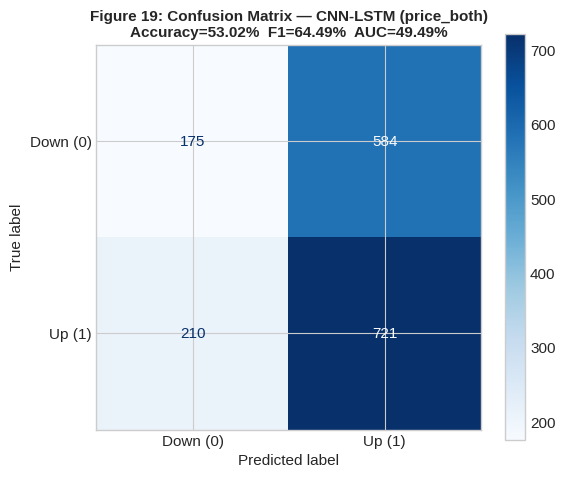

Saved: fig19_confusion_best_model.png


In [12]:
# Cell 12 — Figure 19: Confusion matrix — best overall model
best_overall = max(lstm_results + cnn_results, key=lambda r: r['AUC_ROC'])
best_name    = best_overall['Model']
best_cfg     = best_overall['Config']
sd           = seq_datasets[best_cfg]

print(f'Best overall model: {best_name} ({best_cfg})')
print(f'  AUC-ROC : {best_overall["AUC_ROC"]}%')
print(f'  Accuracy: {best_overall["Accuracy"]}%')
print(f'  F1      : {best_overall["F1"]}%')

cm = confusion_matrix(sd['y_test'], best_overall['y_pred'])
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down (0)','Up (1)'])
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f'Figure 19: Confusion Matrix — {best_name} ({best_cfg})\n'
             f'Accuracy={best_overall["Accuracy"]}%  F1={best_overall["F1"]}%  '
             f'AUC={best_overall["AUC_ROC"]}%',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig19_confusion_best_model.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig19_confusion_best_model.png')

In [13]:
# Cell 13 — Final complete summary
print('=' * 65)
print('FINAL COMPLETE RESULTS — ALL 5 MODELS × 4 CONFIGS')
print('=' * 65)

if classical_df is not None:
    print('\n--- Classical Models ---')
    print(classical_df[['Model','Config','Accuracy','F1','Precision','Recall','AUC_ROC']].to_string(index=False))

print('\n--- Deep Learning Models ---')
print(dl_results_df[['Model','Config','Accuracy','F1','Precision','Recall','AUC_ROC','best_epoch']].to_string(index=False))

print('\n--- Ablation Summary (Accuracy: price_only → price_both) ---')
all_model_names = ['Logistic Regression','SVM','Random Forest','LSTM','CNN-LSTM']
if classical_df is not None:
    combined = pd.concat([classical_df, dl_results_df], ignore_index=True)
else:
    combined = dl_results_df.copy()

for mn in all_model_names:
    sub = combined[combined['Model']==mn]
    if len(sub) == 0: continue
    base_row = sub[sub['Config']=='price_only']
    both_row = sub[sub['Config']=='price_both']
    if len(base_row) and len(both_row):
        base = base_row['Accuracy'].values[0]
        both = both_row['Accuracy'].values[0]
        print(f'  {mn:22s}: {base:.2f}% → {both:.2f}%  ({both-base:+.2f}pp)')

print('\n--- Best Overall Model ---')
best = combined.loc[combined['AUC_ROC'].idxmax()]
print(f'  {best["Model"]} | {best["Config"]} | Acc={best["Accuracy"]}% | F1={best["F1"]}% | AUC={best["AUC_ROC"]}%')

print('\n--- Figures Saved ---')
for fig_name in ['fig16_ablation_heatmap','fig17_roc_all_models',
                 'fig18_training_loss','fig19_confusion_best_model']:
    print(f'  {fig_name}.png')

print('\n=== NB5 COMPLETE ===')
print('All development finished. Ready for dissertation writing.')

FINAL COMPLETE RESULTS — ALL 5 MODELS × 4 CONFIGS

--- Classical Models ---
              Model        Config  Accuracy    F1  Precision  Recall  AUC_ROC
Logistic Regression    price_only     53.60 68.85      54.10   94.63    49.38
Logistic Regression   price_vader     53.07 66.69      54.18   86.72    49.41
Logistic Regression price_finbert     51.22 61.90      53.65   73.14    50.06
Logistic Regression    price_both     51.22 60.36      53.92   68.55    49.97
                SVM    price_only     54.18 70.28      54.18  100.00    50.15
                SVM   price_vader     54.18 70.28      54.18  100.00    50.07
                SVM price_finbert     54.18 70.28      54.18  100.00    50.37
                SVM    price_both     54.18 70.28      54.18  100.00    49.92
      Random Forest    price_only     51.16 56.65      54.57   58.89    51.62
      Random Forest   price_vader     51.43 56.29      54.93   57.71    51.23
      Random Forest price_finbert     50.48 51.80      54.79   49.